# Tutorial 5 — From one sample to many

## 1. Problem / context

A statistic such as the sample mean $\bar{X}$ is itself a random variable. One sample gives one $\bar{x}$. Repeating the sampling process would give many $\bar{x}$ values, and those values have a distribution: the **sampling distribution** of $\bar{X}$.

This tutorial uses a **known population model**, not resampling from an observed data file. The population is right-skewed: individual waiting times follow an exponential distribution with mean $\mu=120$ ms (so the standard deviation is also $\sigma=120$ ms). We draw independent samples directly from that model. Brooks Chapter 5 is the theory; here we watch the sampling distribution by simulation.

Bootstrap resampling from an observed sample is a later estimation idea. It is not the repeated-sampling experiment used to introduce the CLT.

## 2. What the theory claims

If $X_1,\ldots,X_n$ are i.i.d. with mean $\mu$ and variance $\sigma^2$, then

$$
E[\bar{X}]=\mu,
\qquad
\operatorname{Var}(\bar{X})=\frac{\sigma^2}{n},
\qquad
\operatorname{SE}(\bar{X})=\frac{\sigma}{\sqrt{n}}.
$$

Two statements must be kept apart:

- If the population is **normal**, then $\bar{X}\sim N(\mu,\sigma^2/n)$ **exactly**, for every $n$.
- If the population is **not** normal but the observations are i.i.d. with finite variance, the CLT gives the approximation
  $$
\bar{X}\approx N\!\left(\mu,\frac{\sigma^2}{n}\right)
$$
  whose quality depends on the population shape and on $n$. There is no universal rule that $n=30$ is enough.

The **law of large numbers** is a different claim: along one growing sequence, $\bar{x}_n$ tends to concentrate near $\mu$. It says nothing about the shape of the histogram of many sample means.

The CLT does **not** make the raw observations $X_i$ normal, repair dependence or drift, or justify a non-representative sample.

## 3. Simulate independent samples from the exponential population

NumPy's `exponential(scale=...)` uses the mean $1/\lambda$ as `scale`. We take $20{,}000$ repetitions so the histograms of means are stable, and a single generator `default_rng(2026)` so the experiment is reproducible.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, expon

mu = 120.0
sigma = 120.0
n_rep = 20_000
sample_sizes = (1, 4, 25)
rng = np.random.default_rng(2026)

means = {}
for n in sample_sizes:
    samples = rng.exponential(scale=mu, size=(n_rep, n))
    means[n] = samples.mean(axis=1)

rows = []
for n in sample_sizes:
    se = sigma / np.sqrt(n)
    rows.append(
        {
            "n": n,
            "population_mean_mu": mu,
            "mean_of_sample_means": means[n].mean(),
            "theoretical_SE": se,
            "empirical_SD_of_means": means[n].std(ddof=1),
        }
    )
pd.DataFrame(rows)


,n,population_mean_mu,mean_of_sample_means,theoretical_SE,empirical_SD_of_means
0,1,120.0,120.655739,120.0,120.398039
1,4,120.0,119.128157,60.0,59.839347
2,25,120.0,119.731720,24.0,24.008227


The table should show two things: the mean of the simulated $\bar{x}$ values stays near $\mu=120$, and the spread of those means tracks $\sigma/\sqrt{n}$.


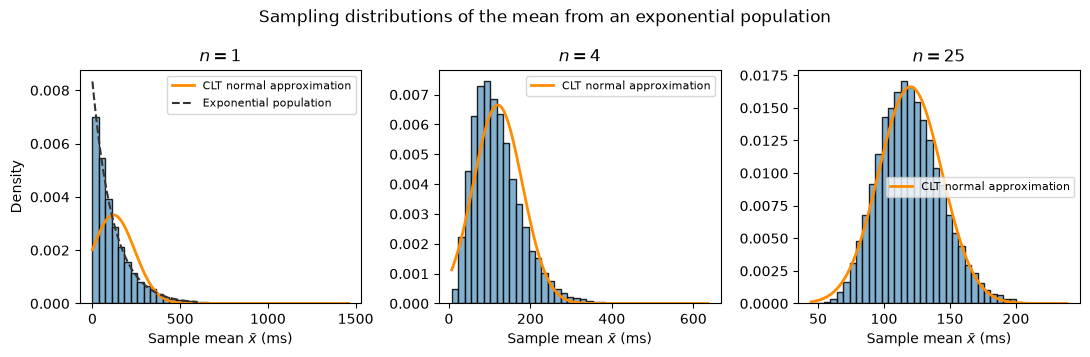

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharey=False)
xs_pop = np.linspace(0, 600, 400)
for ax, n in zip(axes, sample_sizes):
    se = sigma / np.sqrt(n)
    ax.hist(
        means[n],
        bins=40,
        density=True,
        color="#6CA2C6",
        edgecolor="black",
        alpha=0.85,
    )
    x_grid = np.linspace(means[n].min(), means[n].max(), 200)
    ax.plot(
        x_grid,
        norm.pdf(x_grid, loc=mu, scale=se),
        color="#FF8C00",
        lw=2,
        label="CLT normal approximation",
    )
    if n == 1:
        ax.plot(
            xs_pop,
            expon.pdf(xs_pop, scale=mu),
            color="0.2",
            lw=1.5,
            linestyle="--",
            label="Exponential population",
        )
    ax.set_xlabel(r"Sample mean $\bar{x}$ (ms)")
    ax.set_title(rf"$n={n}$")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Density")
fig.suptitle("Sampling distributions of the mean from an exponential population")
plt.tight_layout()
plt.show()


The left panel ($n=1$) is the distribution of individual waiting times: still exponential, still skewed. The orange curve is the CLT approximation $\bar{X}\approx N(\mu,\sigma^2/n)$. It is a poor description at $n=1$, better at $n=4$, and more usable at $n=25$. The approximation is about **means**, not about a single observation becoming normal.

## 4. The law of large numbers, briefly

One growing sequence is enough to see concentration. That is not a sampling distribution.


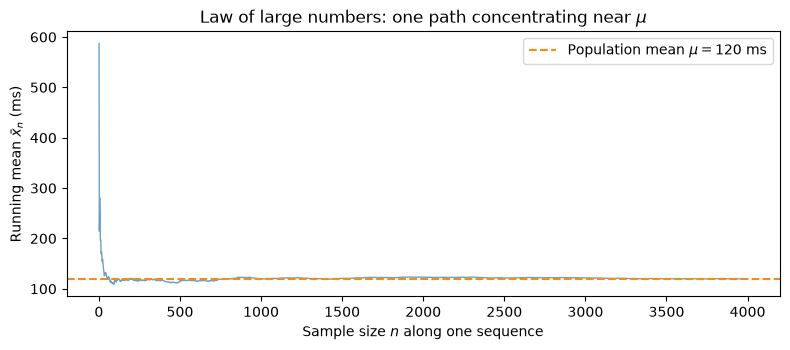

In [3]:
n_lln = 4_000
one_sequence = rng.exponential(scale=mu, size=n_lln)
running_mean = np.cumsum(one_sequence) / np.arange(1, n_lln + 1)

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(np.arange(1, n_lln + 1), running_mean, color="#6CA2C6", lw=1)
ax.axhline(mu, color="#FF8C00", linestyle="--", label=r"Population mean $\mu=120$ ms")
ax.set_xlabel("Sample size $n$ along one sequence")
ax.set_ylabel(r"Running mean $\bar{x}_n$ (ms)")
ax.set_title(r"Law of large numbers: one path concentrating near $\mu$")
ax.legend()
plt.tight_layout()
plt.show()


The running mean wanders less as $n$ grows. That is the LLN. The three histograms above are the CLT picture: many independent samples of a *fixed* $n$, and a shape that becomes more normal.

## 5. A probability for the sample mean

For $n=25$, compare the CLT approximation of $P(\bar{X}>150)$ with the simulated proportion. SciPy's `norm.sf` is $P(\bar{X}>150)$ under the approximating normal.


In [4]:
n = 25
se_25 = sigma / np.sqrt(n)
approx = norm.sf(150, loc=mu, scale=se_25)
simulated = np.mean(means[n] > 150)
print(f"CLT approximation P(bar X > 150) = {approx:.4f}")
print(f"Simulated proportion               = {simulated:.4f}")


CLT approximation P(bar X > 150) = 0.1056
Simulated proportion               = 0.1086


A discrepancy is expected: the population is skewed, so the sampling distribution of $\bar{X}$ at $n=25$ is not exactly normal. The simulated proportion is the better description of *this* exponential experiment; the normal tail is the CLT shortcut.

Pause: if you needed a tail probability for a *single* waiting time $X$, would you use this normal approximation? Why not?

## 6. Common mistakes / things to notice

- Writing $\bar{X}\sim N(\mu,\sigma/\sqrt{n})$. Use variance $\sigma^2/n$ in the normal, and $\operatorname{SE}(\bar{X})=\sigma/\sqrt{n}$ separately.
- Using $\sim$ for the CLT statement when the population is not normal. Reserve $\sim$ for the exact normal-population result; write $\approx$ for the CLT.
- Saying “the data are normal because $n$ is large”, or treating $n=30$ as a universal threshold.
- Confusing one running mean (LLN) with the histogram of many means (sampling distribution / CLT).
- Resampling from an observed CSV and calling that the CLT experiment.

**Conclusion:** For this exponential waiting-time population, $\bar{X}$ stays centred at $120$ ms and its spread shrinks like $1/\sqrt{n}$. The histogram of means becomes closer to $N(120, 120^2/n)$, which is a CLT approximation, not an exact law, and not a statement about individual times.
